In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install wfdb

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

data_dir = '/content/drive/MyDrive/FundamentofDS/'

df = pd.read_csv(os.path.join(data_dir, 'ptbxl_database.csv'), index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

scp_df = pd.read_csv(os.path.join(data_dir, 'scp_statements.csv'), index_col=0)
scp_diag = scp_df[scp_df.diagnostic == 1]

def get_superclasses(scp_dict):
    classes = set()
    for code, val in scp_dict.items():
        if val > 0 and code in scp_diag.index:
            classes.add(scp_diag.loc[code].diagnostic_class)
    return list(classes)

df['superclasses'] = df.scp_codes.apply(get_superclasses)

target_cols = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for col in target_cols:
    df[col] = df['superclasses'].apply(lambda x: 1 if col in x else 0)

df['is_anomaly'] = np.where((df['NORM'] == 1) & (df[target_cols[1:]].sum(axis=1) == 0), 0, 1)

In [ ]:
pd.set_option('display.max_columns', None)

df[['patient_id', 'age', 'sex', 'superclasses', 'NORM', 'MI', 'STTC', 'CD', 'HYP', 'is_anomaly']].head(50)

,patient_id,age,sex,superclasses,NORM,MI,STTC,CD,HYP,is_anomaly
ecg_id,,,,,,,,,,
1,15709.0,56.0,1,[NORM],1,0,0,0,0,0
2,13243.0,19.0,0,[NORM],1,0,0,0,0,0
3,20372.0,37.0,1,[NORM],1,0,0,0,0,0
4,17014.0,24.0,0,[NORM],1,0,0,0,0,0
5,17448.0,19.0,1,[NORM],1,0,0,0,0,0
6,19005.0,18.0,1,[NORM],1,0,0,0,0,0
7,16193.0,54.0,0,[NORM],1,0,0,0,0,0
8,11275.0,48.0,0,[MI],0,1,0,0,0,1
9,18792.0,55.0,0,[NORM],1,0,0,0,0,0


In [ ]:
scp_diag = scp_df[scp_df.diagnostic == 1]

print("Diagnostic:", len(scp_diag))

Diagnostic: 44


In [ ]:
print(df['age'].describe())

missing_age = df['age'].isnull().sum()
print(f"\nNumber of patients missing age information: {missing_age}")

unusual_age = df[(df['age'] <= 0) | (df['age'] > 100)]['age']
if not unusual_age.empty:
    print(f"Detected {len(unusual_age)} abnormal age entries (<=0 or >100):")
    print(unusual_age.value_counts())
else:
    print("No abnormal age values found (<=0 or >100).")

sex_counts = df['sex'].value_counts(dropna=False)
sex_props = df['sex'].value_counts(normalize=True, dropna=False) * 100

sex_summary = pd.DataFrame({'Count': sex_counts, 'Percentage (%)': sex_props.round(2)})
print(sex_summary)

count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

Number of patients missing age information: 0
Detected 293 abnormal age entries (<=0 or >100):
age
300.0    293
Name: count, dtype: int64
     Count  Percentage (%)
sex                       
0    11354           52.08
1    10445           47.92


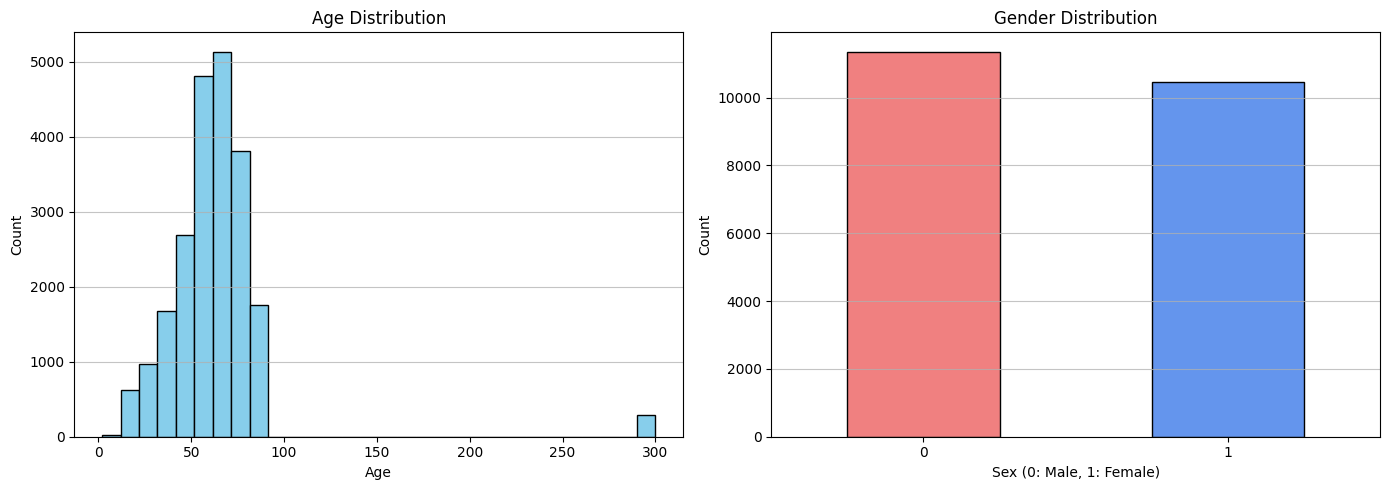

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['age'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
df['sex'].value_counts().plot(kind='bar', color=['lightcoral', 'cornflowerblue'], edgecolor='black')
plt.title('Gender Distribution')
plt.xlabel('Sex (0: Male, 1: Female)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

In [ ]:
min_age_raw = df['age'].min()
max_age_raw = df['age'].max()

print(f"Min age (raw data): {min_age_raw}")
print(f"Max age (raw data): {max_age_raw}")

real_ages = df[df['age'] < 300]['age']

min_age_real = real_ages.min()
max_age_real = real_ages.max()

print(f"\n-> Real min age: {min_age_real}")
print(f"-> Real max age (excluding code 300): {max_age_real}")

Min age (raw data): 2.0
Max age (raw data): 300.0

-> Real min age: 2.0
-> Real max age (excluding code 300): 89.0


In [ ]:
def plot_single_patient_ecg(df, sample_id):
    sample_row = df.loc[sample_id]

    rec_path = sample_row['filename_lr']
    rec_dir = os.path.dirname(rec_path)
    rec_name = os.path.basename(rec_path)

    raw_sig, meta = wfdb.rdsamp(rec_name, pn_dir=f"ptb-xl/1.0.3/{rec_dir}")

    patient_id = sample_row['patient_id']
    age = sample_row['age']
    sex = 'Male' if sample_row['sex'] == 0 else 'Female'
    superclasses = sample_row['superclasses']
    status_str = "NORMAL" if sample_row['is_anomaly'] == 0 else "ANOMALY"
    line_color = 'navy' if sample_row['is_anomaly'] == 0 else 'crimson'

    fig, axes = plt.subplots(6, 2, figsize=(15, 10), sharex=True)
    axes = axes.flatten()
    time_axis = np.linspace(0, 10, raw_sig.shape[0])

    for i in range(12):
        axes[i].plot(time_axis, raw_sig[:, i], color=line_color, lw=1)
        axes[i].set_title(f"Lead: {meta['sig_name'][i]}", fontsize=9, loc='left')
        axes[i].grid(True, linestyle='--', alpha=0.5)

    axes[10].set_xlabel("Time (seconds)")
    axes[11].set_xlabel("Time (seconds)")

    fig.suptitle(f"Single Patient Data Representation (ID: {patient_id} | Record: {sample_id})\n"
                 f"Demographics: Age {age}, Sex: {sex} | Status: {status_str} | Disease Groups: {superclasses}",
                 fontsize=12, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

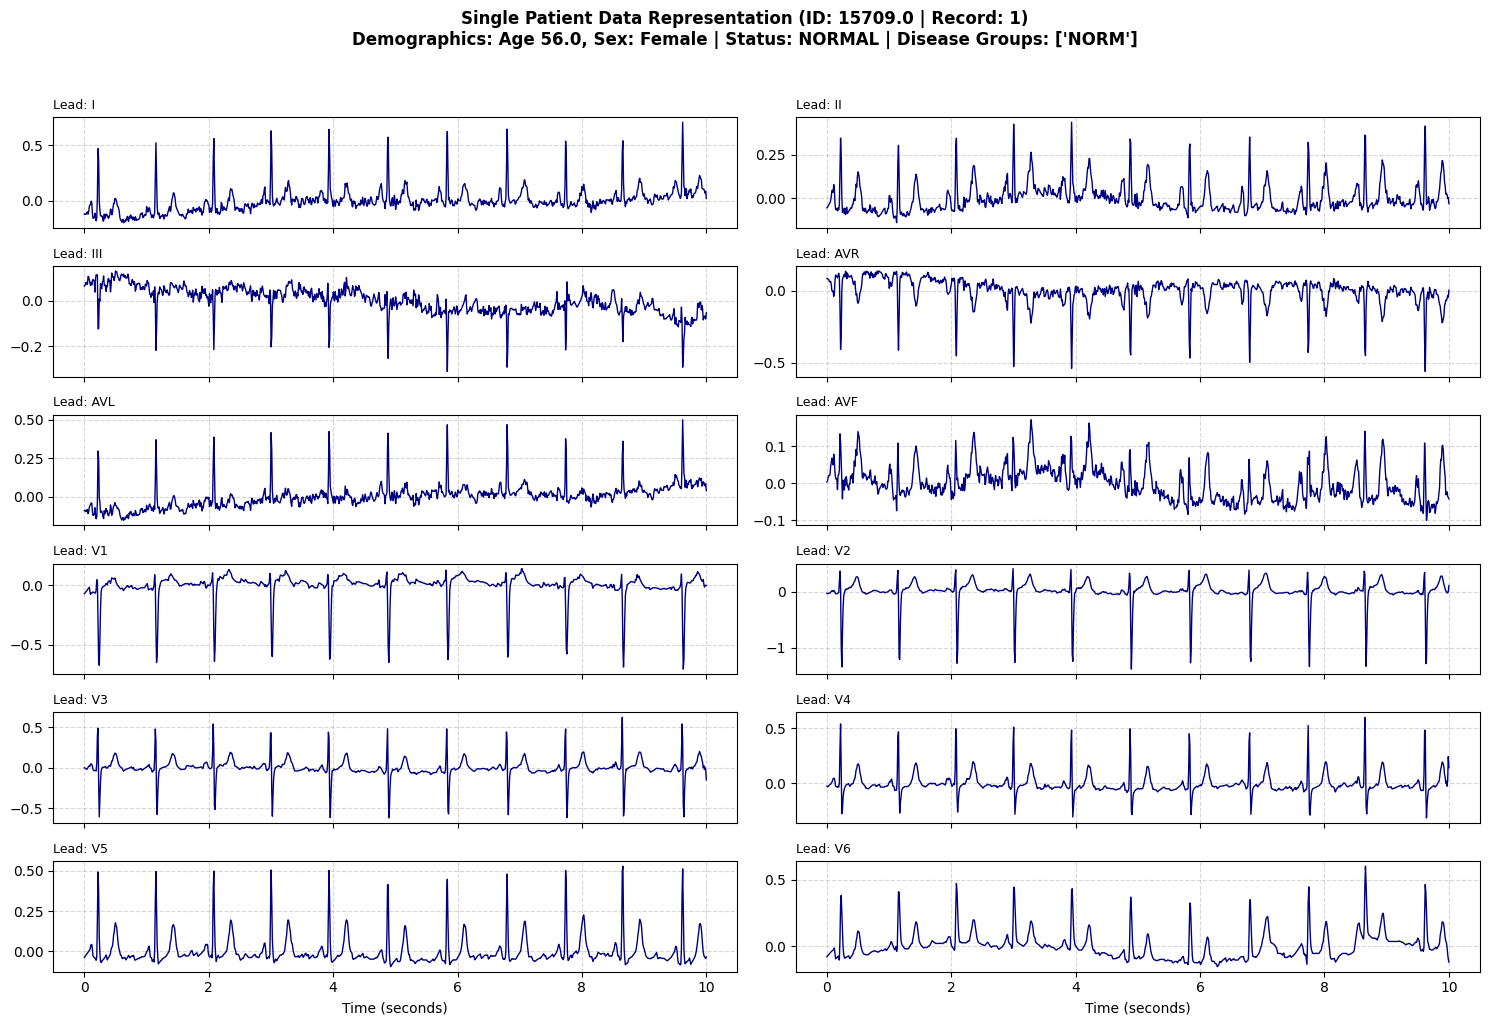

In [ ]:
sample_id = df.index[0]
plot_single_patient_ecg(df, sample_id)

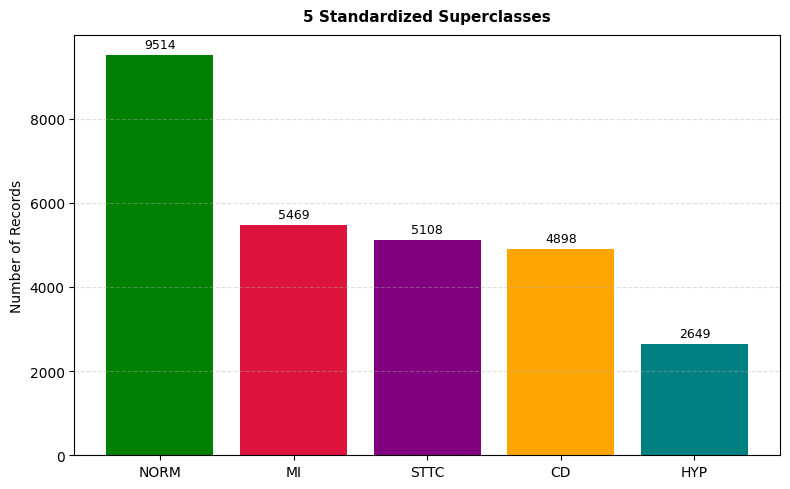

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

superclass_counts = df[target_cols].sum()

colors = ['green', 'crimson', 'purple', 'orange', 'teal']
bars = ax.bar(superclass_counts.index, superclass_counts.values, color=colors)

ax.set_title('5 Standardized Superclasses', fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Number of Records')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

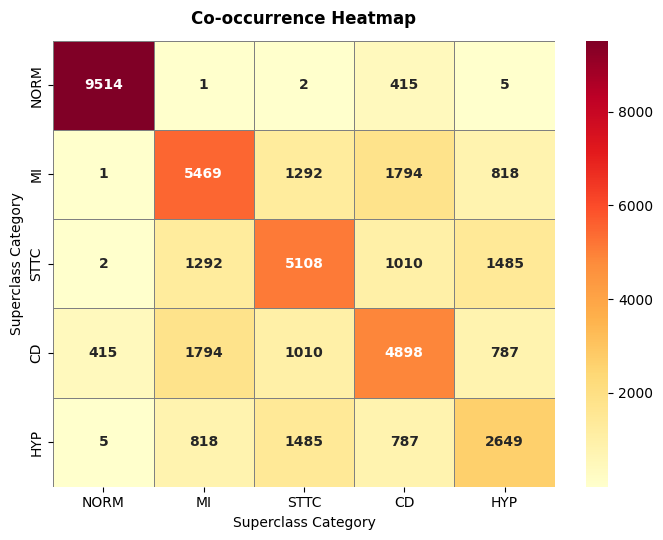

In [ ]:
import seaborn as sns
plt.figure(figsize=(7, 5.5))
co_matrix = df[target_cols].T.dot(df[target_cols])

sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', cbar=True,
            linewidths=0.5, linecolor='gray', annot_kws={"weight": "bold", "size": 10})

plt.title('Co-occurrence Heatmap', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Superclass Category', fontsize=10)
plt.ylabel('Superclass Category', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
multi_disease_patients = df[(df['NORM'] == 1) & (df[['MI', 'STTC', 'CD', 'HYP']].sum(axis=1) >= 2)].copy()

multi_disease_patients['num_diseases'] = multi_disease_patients[['MI', 'STTC', 'CD', 'HYP']].sum(axis=1)

print(multi_disease_patients[['patient_id', 'superclasses', 'num_diseases', 'MI', 'STTC', 'CD', 'HYP']])

        patient_id         superclasses  num_diseases  MI  STTC  CD  HYP
ecg_id                                                                  
1516         555.0     [STTC, CD, NORM]             2   0     1   1    0
3486        5946.0      [HYP, CD, NORM]             2   0     0   1    1
4167       21197.0      [HYP, CD, NORM]             2   0     0   1    1
14292       3580.0  [HYP, CD, MI, NORM]             3   1     0   1    1
16860       2685.0     [STTC, CD, NORM]             2   0     1   1    0


In [ ]:
overlapping_cases = df[(df['NORM'] == 1) & (df[['MI', 'STTC', 'CD', 'HYP']].sum(axis=1) > 0)]
print("Duplicated Sample:", len(overlapping_cases))

Duplicated Sample: 417


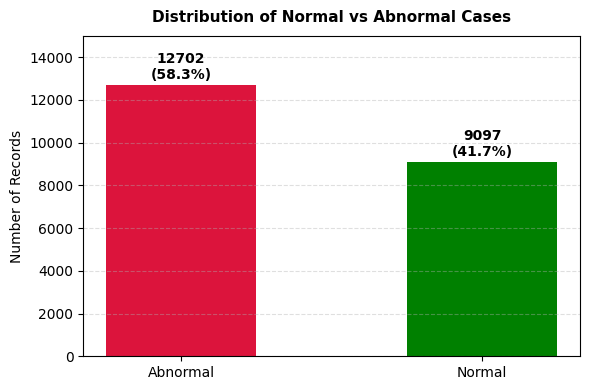

In [ ]:
abnormal_cols = ['MI', 'STTC', 'CD', 'HYP']
is_normal = (df['NORM'] == 1) & (df[abnormal_cols].sum(axis=1) == 0)
df['binary_label'] = np.where(is_normal, 'Normal', 'Abnormal')

plt.figure(figsize=(6, 4))
counts = df['binary_label'].value_counts()

color_map = {'Normal': 'green', 'Abnormal': 'crimson'}
colors = [color_map[label] for label in counts.index]

plt.bar(counts.index, counts.values, color=colors, width=0.5)
plt.title('Distribution of Normal vs Abnormal Cases', fontsize=11, fontweight='bold', pad=10)
plt.ylabel('Number of Records')

for i, v in enumerate(counts.values):
    plt.text(i, v + (max(counts.values) * 0.02), f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

plt.ylim(0, max(counts.values) * 1.18)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
keep_cols = [
    'patient_id', 'age', 'sex', 'height', 'weight', 'strat_fold', 'filename_lr', 'filename_hr',
    'scp_codes', 'superclasses', 'NORM', 'MI', 'STTC', 'CD', 'HYP', 'is_anomaly', 'binary_label'
]

df_clean = df[[col for col in keep_cols if col in df.columns]]

In [20]:
final_data = '/content/drive/MyDrive/FundamentofDS/processed/binary'
output_path = os.path.join(final_data, 'ptbxl_labeled (binary).csv')
df_clean.to_csv(output_path)